In [ ]:
import os
import pandas as pd
import numpy as np
from RS_RTxReadBin import RTxReadBin
import optoanalysis as oa
from scipy.signal import resample
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import joblib
import matplotlib.pyplot as plt
from tensorflow import keras
from keras_tuner import HyperModel
from keras_tuner.tuners import Hyperband

In [ ]:
# Set a fixed number of PSD points for consistency
FIXED_PSD_LENGTH = 512

def extract_psd_features(file_path, max_freq=500e3):

    if file_path.endswith(".bin"):
        y, _, save_info = RTxReadBin(file_path)
        voltages = y[:, 0, 0]
        time_start = save_info["XStart"]
        time_stop = save_info["XStop"]
        signal_record_length = save_info["SignalRecordLength"]
        time_step = (time_stop - time_start) / signal_record_length
        sample_frequency = 1 / time_step

        data = oa.load_voltage_data(voltages, SampleFreq=sample_frequency, timeStart=time_start)

    if file_path.endswith(".trc"):
        data = oa.load_data(file_path)

    freq, psd = data.get_PSD()

    # Filter frequencies
    mask = freq < max_freq
    freq = freq[mask]
    psd = psd[mask]

    # Log scale
    psd = np.log10(psd + 1e-12)

    # Resample PSD to fixed length
    psd_resampled = resample(psd, FIXED_PSD_LENGTH)

    return psd_resampled

In [5]:
# Load manual peak labels
manual_labels = pd.read_csv("manual_peaks.csv")

# Keep only rows marked "Easy fit"
manual_labels = manual_labels[manual_labels['Easy fit'].str.strip().str.lower() == 'yes']

X = []
y = []

for _, row in manual_labels.iterrows():
    file_path = os.path.join("../", row['File Path'])
    try:
        psd_features = extract_psd_features(file_path)
        # Ensure labels are float
        labels = [float(row['f1 (Hz)']), float(row['f2 (Hz)']), float(row['f3 (Hz)'])]
        X.append(psd_features)
        y.append(labels)
    except Exception as e:
        print(f"Failed to process {file_path}: {e}")

X = np.array(X)
y = np.array(y)

print(f"Prepared dataset: {X.shape[0]} samples with {X.shape[1]} features each.")

calcPSD:  True
running self.get_PSD
Calculating power spectral density
Calculating power spectral density
calcPSD:  True
running self.get_PSD
Calculating power spectral density
Calculating power spectral density
calcPSD:  True
running self.get_PSD
Calculating power spectral density
Calculating power spectral density
calcPSD:  True
running self.get_PSD
Calculating power spectral density
Calculating power spectral density
calcPSD:  True
running self.get_PSD
Calculating power spectral density
Calculating power spectral density
calcPSD:  True
running self.get_PSD
Calculating power spectral density
Calculating power spectral density
calcPSD:  True
running self.get_PSD
Calculating power spectral density
Calculating power spectral density
calcPSD:  True
running self.get_PSD
Calculating power spectral density
Calculating power spectral density
calcPSD:  True
running self.get_PSD
Calculating power spectral density
Calculating power spectral density
calcPSD:  True
running self.get_PSD
Calculatin

Trial 90 Complete [00h 00m 05s]
val_mae: 0.46278515458106995

Best val_mae So Far: 0.30546414852142334
Total elapsed time: 00h 03m 52s
Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.1251 - mae: 0.3565 - val_loss: 0.2290 - val_mae: 0.4375 - learning_rate: 0.0029
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1061 - mae: 0.3284 - val_loss: 0.2377 - val_mae: 0.4358 - learning_rate: 0.0029
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1207 - mae: 0.3487 - val_loss: 0.2246 - val_mae: 0.4302 - learning_rate: 0.0029
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1123 - mae: 0.3407 - val_loss: 0.3087 - val_mae: 0.5054 - learning_rate: 0.0029
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0888 - mae: 0.2871 - val_loss: 0.2888 - val_mae: 0.5059 - learning_rate: 0.0029
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0925 - mae: 0.3157 - val_loss: 0.2427 - val_mae: 0.4523 - learning_rate: 0.0029
Epoch 7/100
7/7 ━━━━━━━━━━━━━━

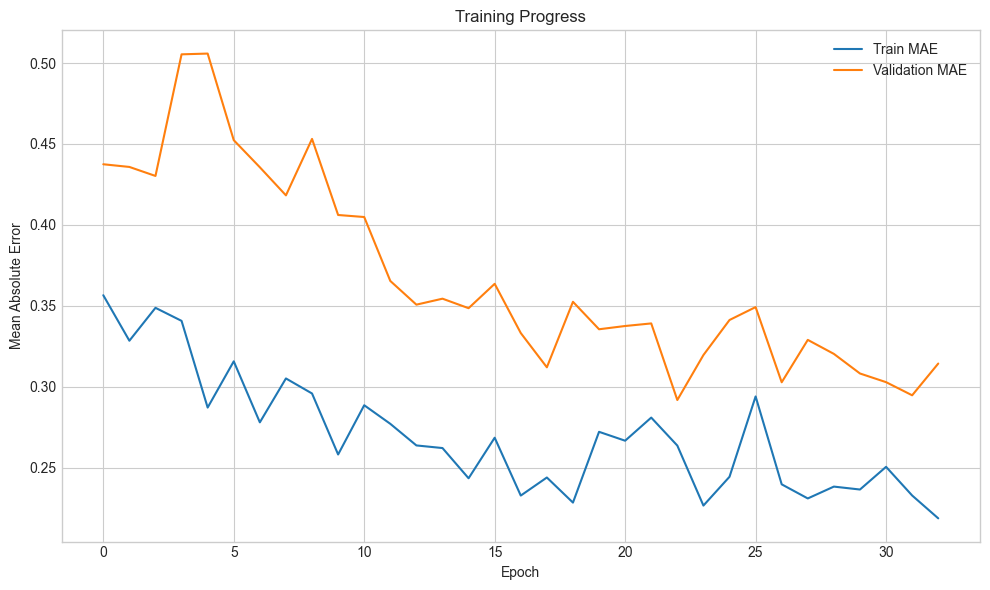

In [ ]:
# ------------------------------
# Step 1: Train/Test Split
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ------------------------------
# Step 2: Scale Inputs and Outputs
# ------------------------------
x_scaler = StandardScaler()
X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)

y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

joblib.dump(x_scaler, "x_scaler_tuned.pkl")
joblib.dump(y_scaler, "y_scaler_tuned.pkl")

# ------------------------------
# Step 3: Hypermodel Definition
# ------------------------------
class MyHyperModel(HyperModel):
    def build(self, hp):
        model = Sequential()
        model.add(Dense(
            units=hp.Int('units_input', min_value=64, max_value=512, step=64),
            activation='relu',
            input_shape=(X_train_scaled.shape[1],),
            kernel_initializer='he_normal'))
        model.add(BatchNormalization())
        model.add(Dropout(hp.Float('dropout_input', 0.1, 0.5, step=0.1)))

        for i in range(hp.Int('num_layers', 1, 3)):
            model.add(Dense(
                units=hp.Int(f'units_{i}', min_value=64, max_value=256, step=64),
                activation='relu',
                kernel_initializer='he_normal'))
            model.add(BatchNormalization())
            model.add(Dropout(hp.Float(f'dropout_{i}', 0.1, 0.5, step=0.1)))

        model.add(Dense(3))  # Output layer for 3 regression targets

        model.compile(
            optimizer=keras.optimizers.Adam(
                hp.Float("lr", 1e-4, 1e-2, sampling="log")),
            loss=tf.keras.losses.Huber(),
            metrics=['mae']
        )
        return model

# ------------------------------
# Step 4: Keras Tuner Setup
# ------------------------------
tuner = Hyperband(
    MyHyperModel(),
    objective='val_mae',
    max_epochs=50,
    factor=3,
    overwrite=True,
    directory='tuner_dir',
    project_name='peak_predictor_tuning'
)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)

tuner.search(
    X_train_scaled, y_train_scaled,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, lr_reducer],
    verbose=1
)

# ------------------------------
# Step 5: Get Best Model & Train Further (optional)
# ------------------------------
best_model = tuner.get_best_models(num_models=1)[0]

# Further fine-tuning (optional)
history = best_model.fit(
    X_train_scaled, y_train_scaled,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, lr_reducer],
    verbose=1
)

# ------------------------------
# Step 6: Evaluate the Model
# ------------------------------
y_pred_scaled = best_model.predict(X_test_scaled)
y_pred = y_scaler.inverse_transform(y_pred_scaled)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"\nFinal MAE (unscaled): {mae:.4f}")
print(f"R² Score: {r2:.4f}")

# ------------------------------
# Step 7: Save the Model
# ------------------------------
best_model.save("peak_predictor_model_tuned.keras")

# ------------------------------
# Step 8: Plot Training History
# ------------------------------
plt.figure(figsize=(10, 6))
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title("Training Progress")
plt.xlabel("Epoch")
plt.ylabel("Mean Absolute Error")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
